In [ ]:
%matplotlib widget

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import ipywidgets as widgets
from matplotlib.widgets import Button, Slider

import numpy as np
import datetime
import time
import os
import cv2

from PIL import Image
from helpers.definitions import *
from helpers.plotting import *
from helpers.json_handling import *
from helpers.pose_construction import *

import distinctipy

In [2]:
folder_path = "output"  # Folder containing JSON files
num_keypoints = 67  # Number of keypoints in your dataset
remove_features = None #[15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
num_cameras = len(cam_names)  # Adjust to the number of cameras in your setup
num_frames = 62
vis_idx = 0
start_frame = 0
output_folder = "output_3d"
identifier = '_hands_2'
poses_2d_file = f'output/updated_poses{identifier}.npz'
take_corrected = True

if os.path.exists(poses_2d_file) and take_corrected:
    data = np.load(poses_2d_file)
    poses_2d = data['poses_2d']
    print(poses_2d.shape)
else:
    poses_2d = read_keypoints_from_json(folder_path, num_keypoints, cam_names, num_frames, start_frame=start_frame, suffix='_keypoints', identifier=None, remove_features=remove_features, hands=False, body=True)
poses_2d_masked = mask_keypoints(poses_2d, confidence_threshold=0.3, min_cameras=2)

suffix = ""
video_dirs = []
for cam_name in cam_names:
    video_dirs.append(os.path.join('examples', 'media', f'{cam_name}_selected{identifier}.mp4'))

# Specify the frame to be loaded
frame_idx = 0 # start frame
keypoint_idx = -1 # start keypoint_idx
cam_name = "gopro1" # start camera
cam_idx = cam_names.index(cam_name)
keypoint_list = list(range(num_keypoints))
keypoint_list.insert(0, -1)
output_path = f"output/updated_poses{identifier}.npz"
advance = 0

(751, 7, 67, 3)


Dropdown(description='Keypoint:', options=(-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 1…

Dropdown(description='Camera:', options=('gopro1', 'gopro2', 'gopro3', 'gopro5', 'gopro9', 'gopro10', 'zoom'),…

Dropdown(description='Advance:', index=1, options=(-1, 0, 1), value=0)

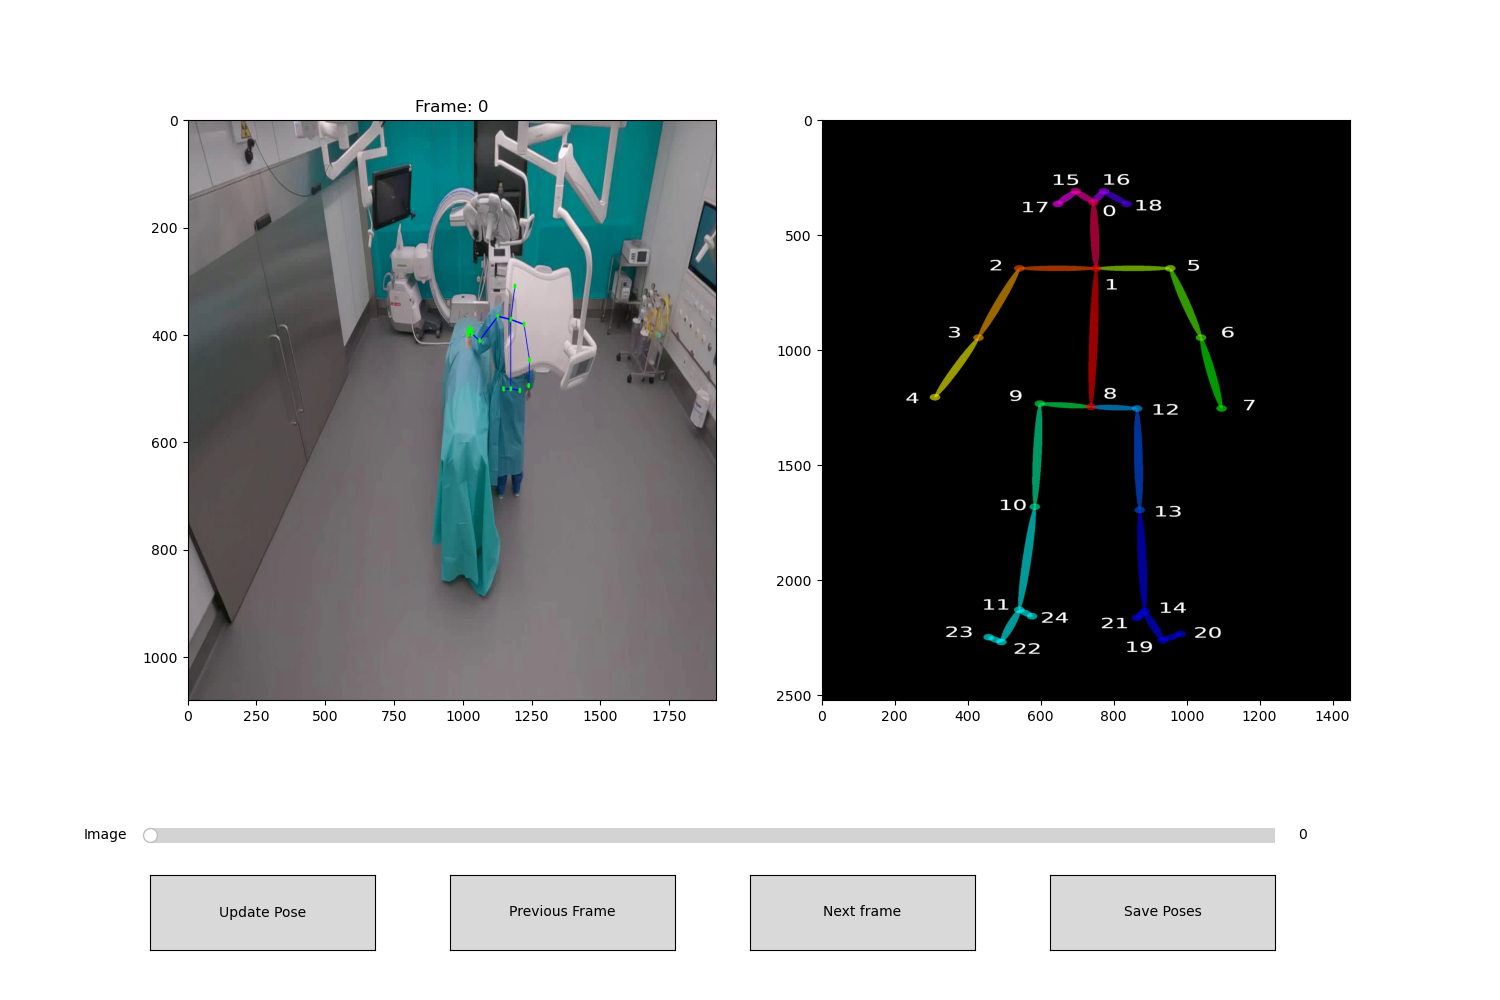

Advance step changed to: 1
Advance step changed to: -1
Camera changed to: zoom
Keypoint idx changed to: 45
Clicked at: (x=1211, y=442). 45 updated
Clicked at: (x=1131, y=504). 44 updated
Clicked at: (x=1044, y=507). 43 updated
Clicked at: (x=1095, y=425). 42 updated
Clicked at: (x=1055, y=416). 41 updated
Clicked at: (x=1018, y=455). 40 updated
Clicked at: (x=949, y=459). 39 updated
Clicked at: (x=978, y=343). 38 updated
Advance step changed to: 0
Keypoint idx changed to: 38
Clicked at: (x=1116, y=247). 38 updated
Keypoint idx changed to: 42
Clicked at: (x=1214, y=342). 42 updated
Advance step changed to: -1


In [3]:
# Load the given frame
video = cv2.VideoCapture(video_dirs[cam_idx])  # Replace with your image path
if not video.isOpened():
        raise FileNotFoundError(f"Cannot open video file: {video_dirs[0]}")

# Set the video to the nth frame
video.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

# Read the frame
success, frame = video.read()
if not success:
    raise ValueError(f"Frame {frame_idx} does not exist in the video.")
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) 

frame = draw_keypoints_and_lines(frame, poses_2d_masked[frame_idx][cam_idx], color_lines=(0, 0, 255))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))
plt.subplots_adjust(bottom=0.3) 
ax1.set_title("Frame: {}".format(frame_idx))
img_display = ax1.imshow(frame, aspect='auto')

image = mpimg.imread('keypoints_pose_25.png')
ax2.imshow(image, aspect='auto')
color_map = distinctipy.get_colors(num_keypoints)

# Function that will be called when you click on the image
def onclick(event):
    global cam_idx
    global frame_idx
    global keypoint_idx
    # Check if the click is within the axes
    if event.inaxes == ax1 and keypoint_idx != -1:
        x, y = int(event.xdata), int(event.ydata)
        ax1.plot(x, y, 'o', color=color_map[keypoint_idx], ms=2)
        poses_2d[frame_idx][cam_idx][keypoint_idx] = (x,y,1)
        poses_2d_masked[frame_idx][cam_idx][keypoint_idx] = (x,y)
        print(f'Clicked at: (x={x}, y={y}). {keypoint_idx} updated')
        fig.canvas.draw()
        if advance != 0:
            keypoint_idx_new = keypoint_idx + advance
            if keypoint_idx >= 0 and keypoint_idx <= 66:
                keypoint_idx = keypoint_idx_new

def submit_points(event):
    global cam_idx
    global frame_idx
    global keypoint_idx
    global frame, video, img_display

    video.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    success, frame = video.read()
    if not success:
        raise ValueError(f"Frame {frame_idx} does not exist in the video.")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    frame = draw_keypoints_and_lines(frame, poses_2d_masked[frame_idx][cam_idx], color_lines=(0, 0, 255))
    ax1.clear()
    img_display = ax1.imshow(frame, aspect='auto')
    ax1.set_title("Frame: {}".format(frame_idx))
    
def next_frame(event):
    global cam_idx
    global frame_idx
    global frame, video, img_display
    if frame_idx < num_frames - 1:
        frame_idx += 1
        video.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

        # Read the frame
        success, frame = video.read()
        if not success:
            raise ValueError(f"Frame {frame_idx} for cam {cam_idx}:{cam_name} does not exist in the video.")
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        frame = draw_keypoints_and_lines(frame, poses_2d_masked[frame_idx][cam_idx], color_lines=(0, 0, 255))
        img_display.set_data(frame)  # Update the image displayed
        ax1.set_title("Frame: {}".format(frame_idx))

    
def previous_frame(event):
    global cam_idx
    global frame_idx
    global frame, video, img_display
    if frame_idx > 0:
        frame_idx -= 1
        video.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

        # Read the frame
        success, frame = video.read()
        if not success:
            raise ValueError(f"Frame {frame_idx} does not exist in the video.")
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        frame = draw_keypoints_and_lines(frame, poses_2d_masked[frame_idx][cam_idx], color_lines=(0, 0, 255))
        img_display.set_data(frame)  # Update the image displayed
        ax1.set_title("Frame: {}".format(frame_idx))

     
    
def update_image(val):
    global cam_idx, frame_idx, frame, video
    frame_idx = int(val)
    video.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

    # Read the frame
    success, frame = video.read()
    if not success:
        raise ValueError(f"Frame {frame_idx} does not exist in the video.")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    frame = draw_keypoints_and_lines(frame, poses_2d_masked[frame_idx][cam_idx], color_lines=(0, 0, 255))
    img_display.set_data(frame)  # Update the image displayed
    ax1.set_title("Frame: {}".format(frame_idx))

def dropdown_change(change):
    global keypoint_idx, keypoint_list
    keypoint_idx = change['new']
    print(f'Keypoint idx changed to: {keypoint_idx}')

def dropdown2_change(change):
    global cam_name, cam_names, cam_idx, video, frame, frame_idx
    cam_name = change['new']
    cam_idx = cam_names.index(cam_name)

    # Load the given frame
    video = cv2.VideoCapture(video_dirs[cam_idx])  # Replace with your image path
    if not video.isOpened():
            raise FileNotFoundError(f"Cannot open video file: {video_dirs[0]}")

    # Set the video to the nth frame
    video.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

    # Read the frame
    success, frame = video.read()
    if not success:
        raise ValueError(f"Frame {frame_idx} does not exist in the video.")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    frame = draw_keypoints_and_lines(frame, poses_2d_masked[frame_idx][cam_idx], color_lines=(0, 0, 255))
    img_display.set_data(frame)
    print(f'Camera changed to: {cam_name}')

def dropdown3_change(change):
    global advance
    advance = change['new']
    print(f"Advance step changed to: {advance}")

def save_poses(event):
    np.savez(output_path, poses_2d=np.array(poses_2d))
    

# Create a button to switch the color
axsubmit = plt.axes([0.1, 0.05, 0.15, 0.075])
btn_submit = Button(axsubmit, 'Update Pose')
btn_submit.on_clicked(submit_points)
axprev = plt.axes([0.3, 0.05, 0.15, 0.075])
btn_prev = Button(axprev, 'Previous Frame')
btn_prev.on_clicked(previous_frame)
axnext = plt.axes([0.5, 0.05, 0.15, 0.075])
btn_next = Button(axnext, 'Next frame')
btn_next.on_clicked(next_frame)
axsave = plt.axes([0.7, 0.05, 0.15, 0.075])
btn_save = Button(axsave, 'Save Poses')
btn_save.on_clicked(save_poses)

axslider = plt.axes([0.1, 0.15, 0.75, 0.03], facecolor='lightgoldenrodyellow')
slider = Slider(axslider, 'Image', 0, num_frames - 1, valinit=0, valstep=1)
slider.on_changed(update_image)

dropdown = widgets.Dropdown(
    options=keypoint_list,
    value=keypoint_list[0],
    description='Keypoint:',
    disabled=False,
)
dropdown.observe(dropdown_change, names='value')
display(dropdown)
dropdown2 = widgets.Dropdown(
    options=cam_names,
    value=cam_name,
    description='Camera:',
    disabled=False,
)
dropdown2.observe(dropdown2_change, names='value')
display(dropdown2)
dropdown3 = widgets.Dropdown(
    options=[-1, 0, 1],
    value=advance,
    description='Advance:',
    disabled=False,
)
dropdown3.observe(dropdown3_change, names='value')
display(dropdown3)

# Connect the click event to the function
cid = fig.canvas.mpl_connect('button_press_event', onclick)

# Display the plot inline
plt.show()

In [4]:
video.release()